# 전기차(EV) 주행 조건별 에너지 소비량 예측 — 데이터 탐색(EDA)

## 프로젝트 개요
- **목표**: 주행 조건(속도, 적재중량, 외기온도, HVAC 사용량, 도로 경사도, 배터리 온도, 운전 성향, 타이어 공기압, 주행 거리)이 `100km 당 에너지소비량`(100km당 에너지 소비량)에 미치는 영향을 파악합니다.
- **팀 프로젝트 방향**: 단순 회귀 모델 구축에서 그치지 않고, 이 모델을 **어떤 문제를 해결하는 솔루션**에 적용할 수 있을지(예: 주행 가능 거리 예측, 에코 드라이빙 코칭, 효율적인 경로 추천 등) 확장하는 것이 최종 목표입니다.
- **이번 단계(EDA)의 진행 순서**
    1. 데이터 구성 파악 (shape, dtype, 기초 통계)
    2. 결측치 / 중복 데이터 확인
    3. 변수별 분포 확인 (히스토그램)
    4. 타겟 변수 분포 및 이상치 탐색
    5. 변수 간 상관관계 분석 (히트맵 + 타겟과의 상관계수)
    6. 주요 변수와 타겟 간 산점도로 관계 형태 확인
    7. 다음 단계(문제 정의)로 넘어가기 위한 요약


In [31]:
# 데이터 처리 및 시각화를 위한 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# 한글 폰트 설정 (Linux 환경 기준, 다른 실습 노트북과 동일한 방식)
import platform
from matplotlib import rc
plt.rcParams['axes.unicode_minus'] = False
if platform.system() == 'Linux':
    rc('font', family='NanumGothic')
elif platform.system() == 'Windows':
    rc('font', family='Malgun Gothic')


## 데이터 설명

| 컬럼명 | 의미 | 단위 |
|---|---|---|
| 평균 주행 속도 | 평균 주행 속도 | km/h |
| 적재/탑승 중량 | 적재 중량 | kg |
| 외기 온도 | 외기 온도 | °C |
| 냉난방 소비 전력 | 냉난방(HVAC) 전력 사용량 | kW |
| 도로 경사도 | 도로 경사도 (오르막 +, 내리막 -) | % |
| 배터리 온도 | 배터리 온도 | °C |
| 운전 성향 지수 | 운전 성향 지수 (0에 가까울수록 온순, 1에 가까울수록 공격적) | 0~1 |
| 타이어 공기압 | 타이어 공기압 | bar |
| 주행 거리 | 주행 거리 | km |
| **100km 당 에너지소비량** | **[타겟] 100km당 에너지 소비량** | kWh |


In [32]:
# 데이터 로딩 및 발표용 한글 컬럼명 적용
ev_df = pd.read_csv('datas_ml/ev_energy_consumption.csv')

column_name_map = {
    'speed_kmh': '평균 주행 속도',
    'payload_kg': '적재/탑승 중량',
    'ambient_temp_C': '외기 온도',
    'hvac_power_kw': '냉난방 소비 전력',
    'road_grade_pct': '도로 경사도',
    'battery_temp_C': '배터리 온도',
    'driving_style_index': '운전 성향 지수',
    'tire_pressure_bar': '타이어 공기압',
    'trip_distance_km': '주행 거리',
    'energy_consumption_kwhper100km': '100km 당 에너지소비량'
}
ev_df = ev_df.rename(columns=column_name_map)

print('데이터 크기(행, 열):', ev_df.shape)
ev_df.head()


데이터 크기(행, 열): (8000, 10)


,평균 주행 속도,적재/탑승 중량,외기 온도,냉난방 소비 전력,도로 경사도,배터리 온도,운전 성향 지수,타이어 공기압,주행 거리,100km 당 에너지소비량
0,61.2,360.1,-9.8,3.43,-4.65,24.0,0.687,2.38,35.7,25.357
1,124.6,343.6,-10.0,2.34,-4.90,17.8,0.413,2.79,9.1,25.554
2,100.5,47.9,13.6,0.28,-2.08,18.8,0.280,2.58,68.8,18.004
3,85.9,461.3,-8.5,4.59,5.39,20.4,0.616,2.68,165.7,34.539
4,37.2,284.2,38.7,4.90,6.76,21.1,0.740,2.35,8.0,26.883


In [33]:
# 컬럼별 데이터 타입 및 결측 여부 개괄 확인
ev_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   평균 주행 속도        8000 non-null   float64
 1   적재/탑승 중량        8000 non-null   float64
 2   외기 온도           8000 non-null   float64
 3   냉난방 소비 전력       8000 non-null   float64
 4   도로 경사도          8000 non-null   float64
 5   배터리 온도          8000 non-null   float64
 6   운전 성향 지수        8000 non-null   float64
 7   타이어 공기압         8000 non-null   float64
 8   주행 거리           8000 non-null   float64
 9   100km 당 에너지소비량  8000 non-null   float64
dtypes: float64(10)
memory usage: 625.1 KB


In [34]:
# 수치형 변수 기초 통계량 확인 (평균, 표준편차, 최소/최대, 분위수)
ev_df.describe().T


,count,mean,std,min,25%,50%,75%,max
평균 주행 속도,8000.0,74.427013,31.789245,20.00,46.775,74.2000,101.800,130.0
적재/탑승 중량,8000.0,248.822563,144.327869,0.00,124.300,246.8500,376.125,500.0
외기 온도,8000.0,15.587013,14.396150,-10.00,3.475,15.8000,27.900,40.0
냉난방 소비 전력,8000.0,2.477026,1.435208,0.00,1.230,2.4800,3.700,5.0
도로 경사도,8000.0,1.464087,3.744704,-5.00,-1.790,1.5000,4.670,8.0
배터리 온도,8000.0,29.970725,8.717058,15.00,22.300,29.9000,37.700,45.0
운전 성향 지수,8000.0,0.499641,0.286885,0.00,0.254,0.5020,0.745,1.0
타이어 공기압,8000.0,2.401016,0.230790,2.00,2.200,2.4000,2.600,2.8
주행 거리,8000.0,102.692337,55.844911,5.10,54.300,103.2500,151.700,200.0
100km 당 에너지소비량,8000.0,24.137613,3.738082,11.62,21.514,24.0925,26.753,35.0


## 결측치 및 중복 데이터 확인

본격적인 분포/상관관계 분석에 들어가기 전에, 데이터 품질(결측치·중복 행)부터 점검합니다.


In [35]:
# 컬럼별 결측치 개수
print('[결측치 개수]')
print(ev_df.isnull().sum())

# 완전히 동일한 행(중복 데이터) 개수
print('\n[중복 행 개수]', ev_df.duplicated().sum())


[결측치 개수]
평균 주행 속도          0
적재/탑승 중량          0
외기 온도             0
냉난방 소비 전력         0
도로 경사도            0
배터리 온도            0
운전 성향 지수          0
타이어 공기압           0
주행 거리             0
100km 당 에너지소비량    0
dtype: int64

[중복 행 개수] 0


## 변수별 분포 확인

각 변수가 어떤 범위와 형태(정규분포/치우침 등)로 분포하는지 히스토그램으로 확인합니다.


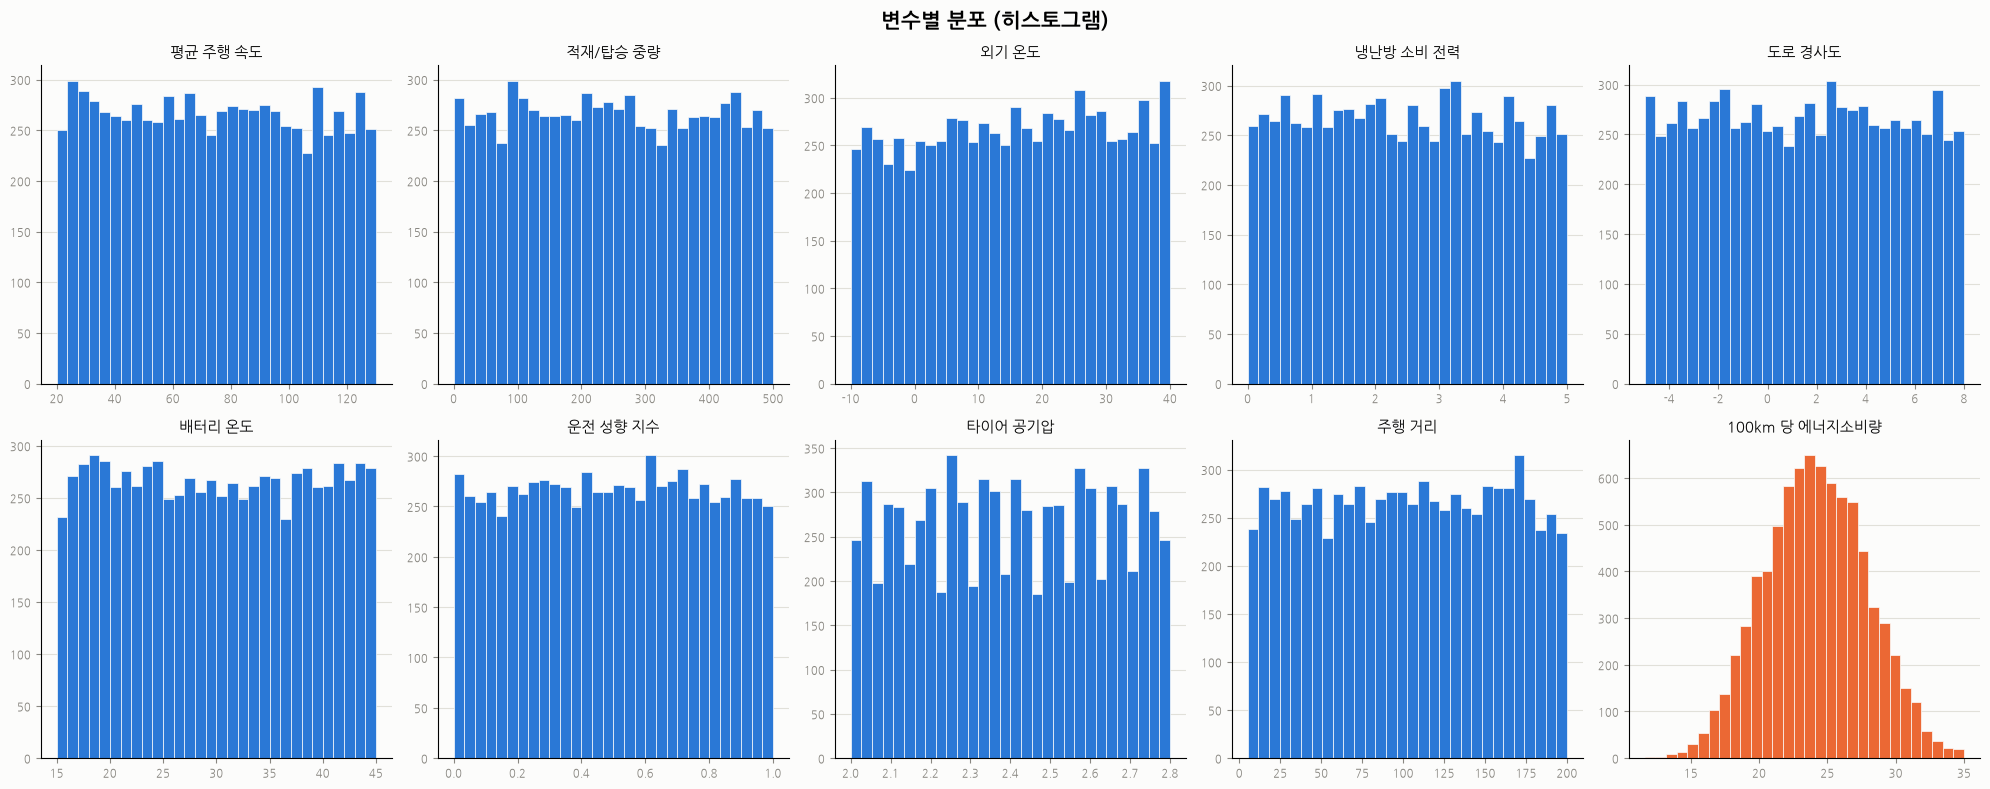

In [36]:
# 전체 수치형 변수(타겟 포함)의 분포를 한 번에 확인하기 위한 히스토그램 그리드
feature_cols = ['평균 주행 속도', '적재/탑승 중량', '외기 온도', '냉난방 소비 전력',
                '도로 경사도', '배터리 온도', '운전 성향 지수',
                '타이어 공기압', '주행 거리']
target_col = '100km 당 에너지소비량'
all_cols = feature_cols + [target_col]

# 색상 팔레트: 입력 변수(파랑) / 타겟(주황)을 구분해서 지정
COLOR_FEATURE = '#2a78d6'
COLOR_TARGET = '#eb6834'
INK_PRIMARY = '#0b0b0b'
INK_MUTED = '#898781'
GRID_COLOR = '#e1e0d9'
SURFACE = '#fcfcfb'

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.patch.set_facecolor(SURFACE)
axes = axes.flatten()

for i, col in enumerate(all_cols):
    ax = axes[i]
    ax.set_facecolor(SURFACE)
    color = COLOR_TARGET if col == target_col else COLOR_FEATURE
    ax.hist(ev_df[col], bins=30, color=color, edgecolor=SURFACE, linewidth=0.5)
    ax.set_title(col, fontsize=11, color=INK_PRIMARY)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(colors=INK_MUTED, labelsize=8)
    ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.8)
    ax.set_axisbelow(True)

fig.suptitle('변수별 분포 (히스토그램)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


## 타겟 변수(에너지 소비량) 분포 자세히 보기

예측 대상인 `100km 당 에너지소비량`의 분포와 이상치 여부를 별도로 확인합니다.


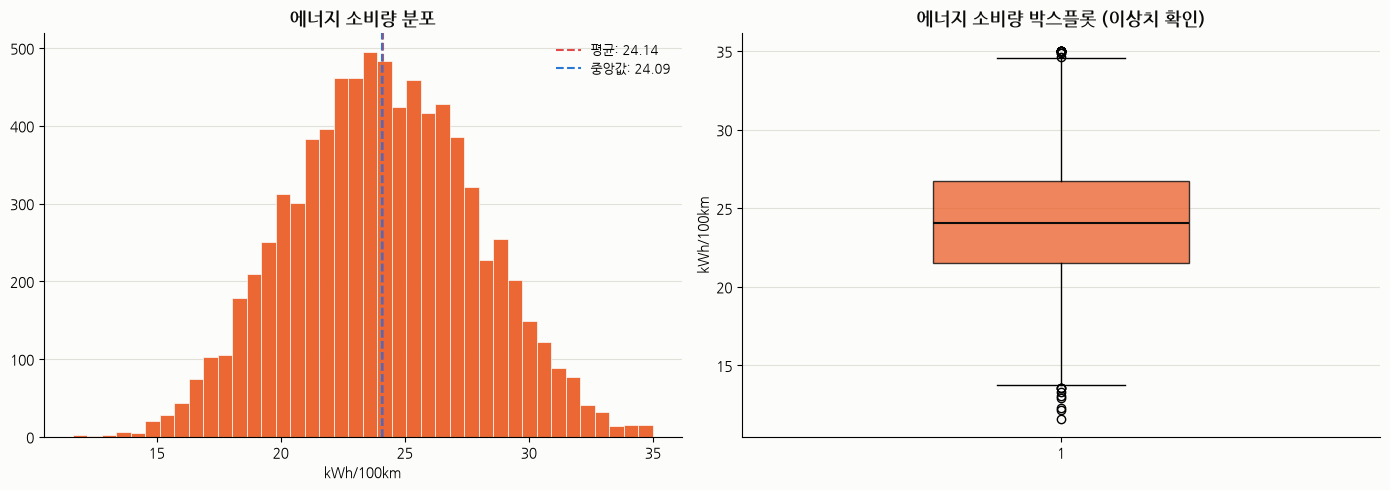

IQR 기준 이상치(1.5*IQR 벗어난 값) 개수: 21개 (0.26%)


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(SURFACE)

# 1) 히스토그램 + 평균/중앙값 표시
ax0 = axes[0]
ax0.set_facecolor(SURFACE)
ax0.hist(ev_df[target_col], bins=40, color=COLOR_TARGET, edgecolor=SURFACE, linewidth=0.5)
mean_val = ev_df[target_col].mean()
median_val = ev_df[target_col].median()
ax0.axvline(mean_val, color='#e34948', linestyle='--', linewidth=1.5, label=f'평균: {mean_val:.2f}')
ax0.axvline(median_val, color='#2a78d6', linestyle='--', linewidth=1.5, label=f'중앙값: {median_val:.2f}')
ax0.set_title('에너지 소비량 분포', fontsize=13, fontweight='bold', color=INK_PRIMARY)
ax0.set_xlabel('kWh/100km')
ax0.legend(frameon=False, fontsize=9)
ax0.spines['top'].set_visible(False)
ax0.spines['right'].set_visible(False)
ax0.yaxis.grid(True, color=GRID_COLOR, linewidth=0.8)
ax0.set_axisbelow(True)

# 2) 박스플롯으로 이상치(사분위수 벗어난 값) 확인
ax1 = axes[1]
ax1.set_facecolor(SURFACE)
bp = ax1.boxplot(ev_df[target_col], orientation='vertical', patch_artist=True, widths=0.4)
for box in bp['boxes']:
    box.set(facecolor=COLOR_TARGET, edgecolor=INK_PRIMARY, alpha=0.8)
for med in bp['medians']:
    med.set(color=INK_PRIMARY, linewidth=1.5)
ax1.set_title('에너지 소비량 박스플롯 (이상치 확인)', fontsize=13, fontweight='bold', color=INK_PRIMARY)
ax1.set_ylabel('kWh/100km')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.yaxis.grid(True, color=GRID_COLOR, linewidth=0.8)
ax1.set_axisbelow(True)

plt.tight_layout()
plt.show()

# IQR(사분위범위) 기준 이상치 개수 정량 확인
q1, q3 = ev_df[target_col].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outlier_count = ((ev_df[target_col] < lower) | (ev_df[target_col] > upper)).sum()
print(f'IQR 기준 이상치(1.5*IQR 벗어난 값) 개수: {outlier_count}개 ({outlier_count / len(ev_df) * 100:.2f}%)')


## 전체 변수 이상치 탐색

타겟뿐 아니라 입력 변수(feature)들도 이상치가 있는지 변수별 박스플롯으로 확인합니다.


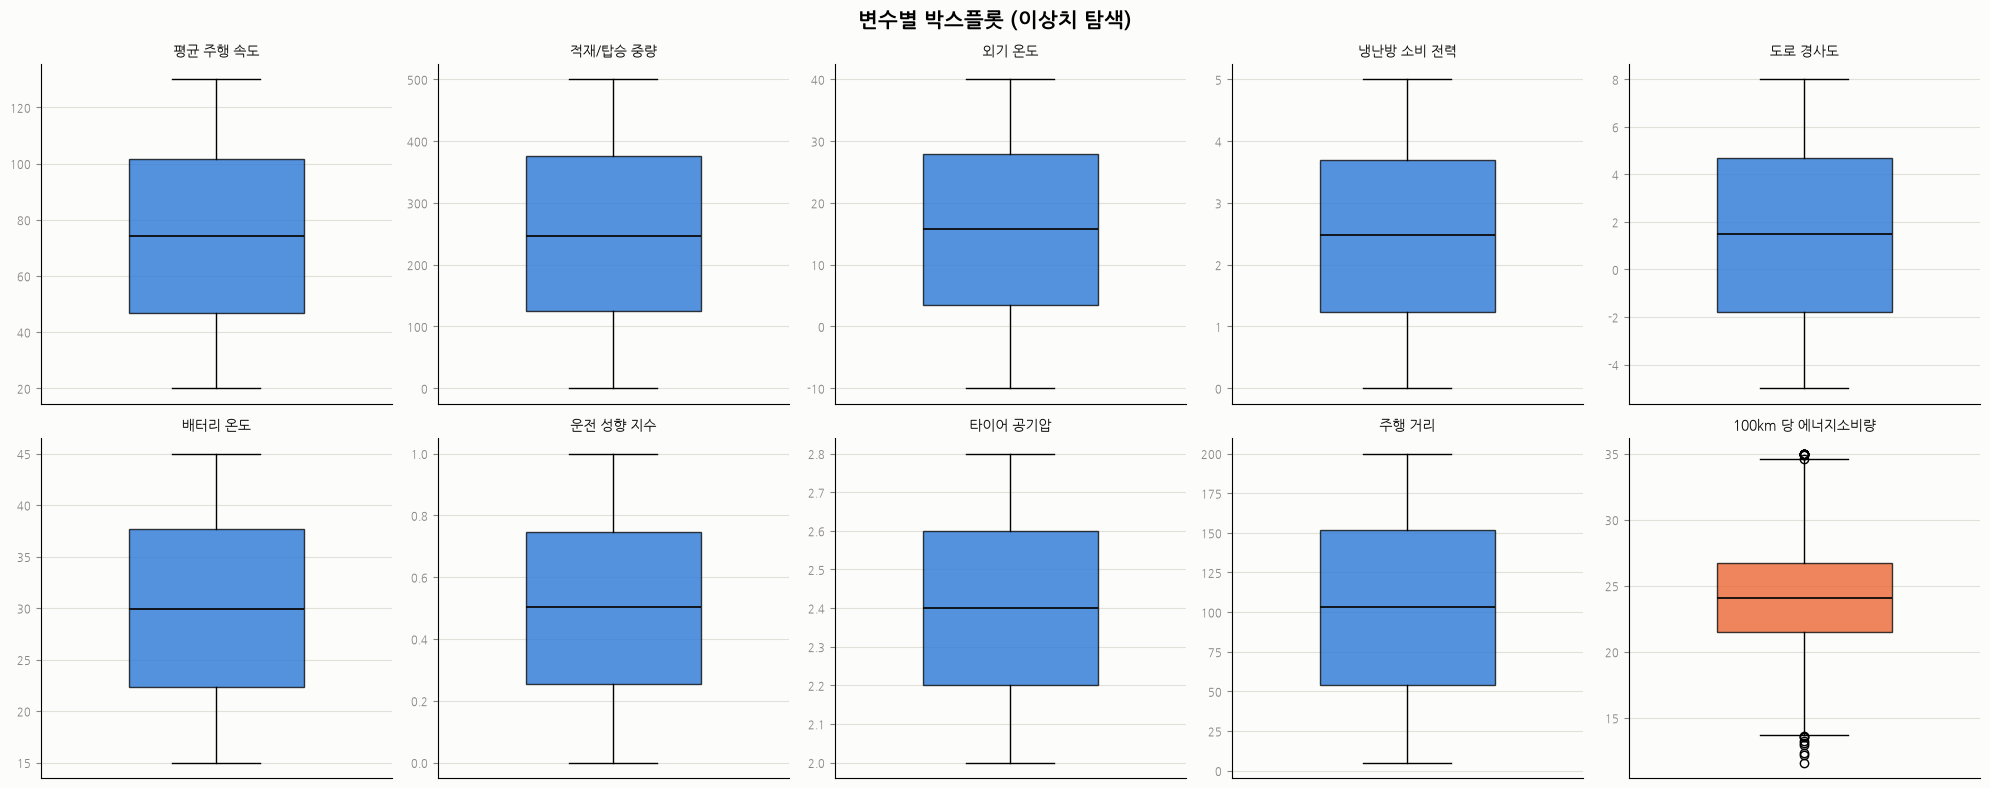

In [38]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.patch.set_facecolor(SURFACE)
axes = axes.flatten()

for i, col in enumerate(all_cols):
    ax = axes[i]
    ax.set_facecolor(SURFACE)
    color = COLOR_TARGET if col == target_col else COLOR_FEATURE
    bp = ax.boxplot(ev_df[col], orientation='vertical', patch_artist=True, widths=0.5)
    for box in bp['boxes']:
        box.set(facecolor=color, edgecolor=INK_PRIMARY, alpha=0.8)
    for med in bp['medians']:
        med.set(color=INK_PRIMARY, linewidth=1.3)
    ax.set_title(col, fontsize=10, color=INK_PRIMARY)
    ax.set_xticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(colors=INK_MUTED, labelsize=8)
    ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.8)
    ax.set_axisbelow(True)

fig.suptitle('변수별 박스플롯 (이상치 탐색)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


## 변수 간 상관관계 분석

- 아래 두 시각화는 팀 프로젝트 요구사항에 따라 **필수로 포함**했습니다.
    1. **전체 변수 간 상관관계 히트맵** — 변수들끼리 서로 얼마나 관련되어 있는지(다중공선성 등) 확인
    2. **에너지 소비량과 각 변수 간 상관계수 막대그래프** — 어떤 변수가 타겟 예측에 중요할지 우선순위 파악

> 참고: Pearson 상관계수는 **선형관계**만 포착합니다. 예를 들어 속도나 온도처럼 U자형(비선형) 관계가 있는 변수는 상관계수가 낮게 나와도 실제로는 중요한 변수일 수 있습니다. 이는 이후 산점도로 다시 확인합니다.


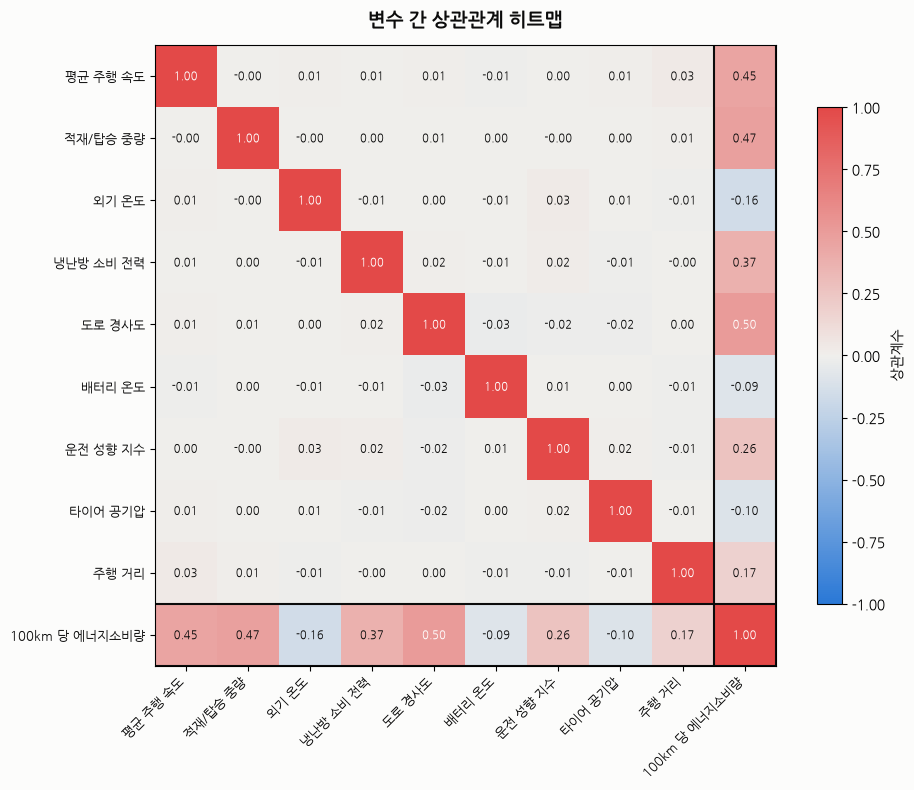

In [39]:
# 상관계수 행렬 계산 (전체 변수 + 타겟)
corr_matrix = ev_df[all_cols].corr()

# 상관관계는 -1~1 사이의 '방향이 있는' 값이므로, 0을 중심으로 하는 diverging(발산형) 컬러맵을 직접 정의
# 음의 상관: 파랑(#2a78d6) / 무관: 회색(#f0efec) / 양의 상관: 빨강(#e34948)
diverging_cmap = LinearSegmentedColormap.from_list(
    'corr_diverging', ['#2a78d6', '#f0efec', '#e34948']
)

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor(SURFACE)
im = ax.imshow(corr_matrix, cmap=diverging_cmap, vmin=-1, vmax=1)

# 축 눈금을 변수명으로 표시
ax.set_xticks(range(len(all_cols)))
ax.set_yticks(range(len(all_cols)))
ax.set_xticklabels(all_cols, rotation=45, ha='right', fontsize=9, color=INK_PRIMARY)
ax.set_yticklabels(all_cols, fontsize=9, color=INK_PRIMARY)

# 각 칸에 상관계수 값을 직접 표기 (값이 클수록 흰 글씨, 작을수록 검은 글씨로 가독성 확보)
for i in range(len(all_cols)):
    for j in range(len(all_cols)):
        val = corr_matrix.iloc[i, j]
        text_color = 'white' if abs(val) > 0.5 else INK_PRIMARY
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8, color=text_color)

# 타겟 행/열을 테두리로 강조 표시
target_idx = all_cols.index(target_col)
ax.axhline(target_idx - 0.5, color=INK_PRIMARY, linewidth=1.5)
ax.axhline(target_idx + 0.5, color=INK_PRIMARY, linewidth=1.5)
ax.axvline(target_idx - 0.5, color=INK_PRIMARY, linewidth=1.5)
ax.axvline(target_idx + 0.5, color=INK_PRIMARY, linewidth=1.5)

cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('상관계수', fontsize=10)

ax.set_title('변수 간 상관관계 히트맵', fontsize=14, fontweight='bold', color=INK_PRIMARY, pad=14)
plt.tight_layout()
plt.show()


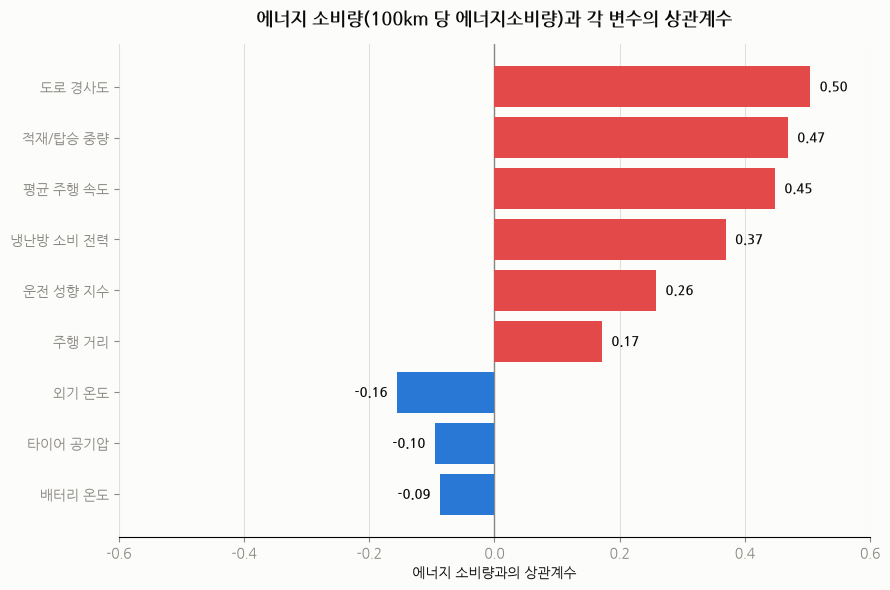

도로 경사도       0.504623
적재/탑승 중량     0.468906
평균 주행 속도     0.448316
냉난방 소비 전력    0.369619
운전 성향 지수     0.258434
주행 거리        0.171982
외기 온도       -0.155499
타이어 공기압     -0.095066
배터리 온도      -0.086873
Name: 100km 당 에너지소비량, dtype: float64


In [40]:
# 타겟(100km 당 에너지소비량)과 각 변수 간의 상관계수만 추출
target_corr = corr_matrix[target_col].drop(target_col).sort_values(key=abs, ascending=True)

# 양의 상관은 빨강, 음의 상관은 파랑으로 구분 (히트맵과 색상 규칙 통일)
bar_colors = ['#e34948' if v > 0 else '#2a78d6' for v in target_corr.values]

fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

bars = ax.barh(target_corr.index, target_corr.values, color=bar_colors, zorder=3)

for bar, val in zip(bars, target_corr.values):
    x_pos = val + (0.015 if val > 0 else -0.015)
    ha = 'left' if val > 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height() / 2, f'{val:.2f}',
            va='center', ha=ha, fontsize=9, color=INK_PRIMARY, fontweight='bold')

ax.axvline(0, color=INK_MUTED, linewidth=1)
ax.set_xlim(-0.6, 0.6)
ax.set_xlabel('에너지 소비량과의 상관계수', fontsize=10, color=INK_PRIMARY)
ax.set_title('에너지 소비량(100km 당 에너지소비량)과 각 변수의 상관계수',
             fontsize=13, fontweight='bold', color=INK_PRIMARY, pad=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.xaxis.grid(True, color=GRID_COLOR, linewidth=0.8, zorder=0)
ax.tick_params(colors=INK_MUTED)

plt.tight_layout()
plt.show()

print(target_corr.sort_values(key=abs, ascending=False))


## 주요 변수와 타겟 간 관계 시각화 (산점도)

상관계수 절댓값 기준 상위 변수들을 골라, 실제로 어떤 형태(선형/비선형)의 관계인지 산점도로 직접 확인합니다.


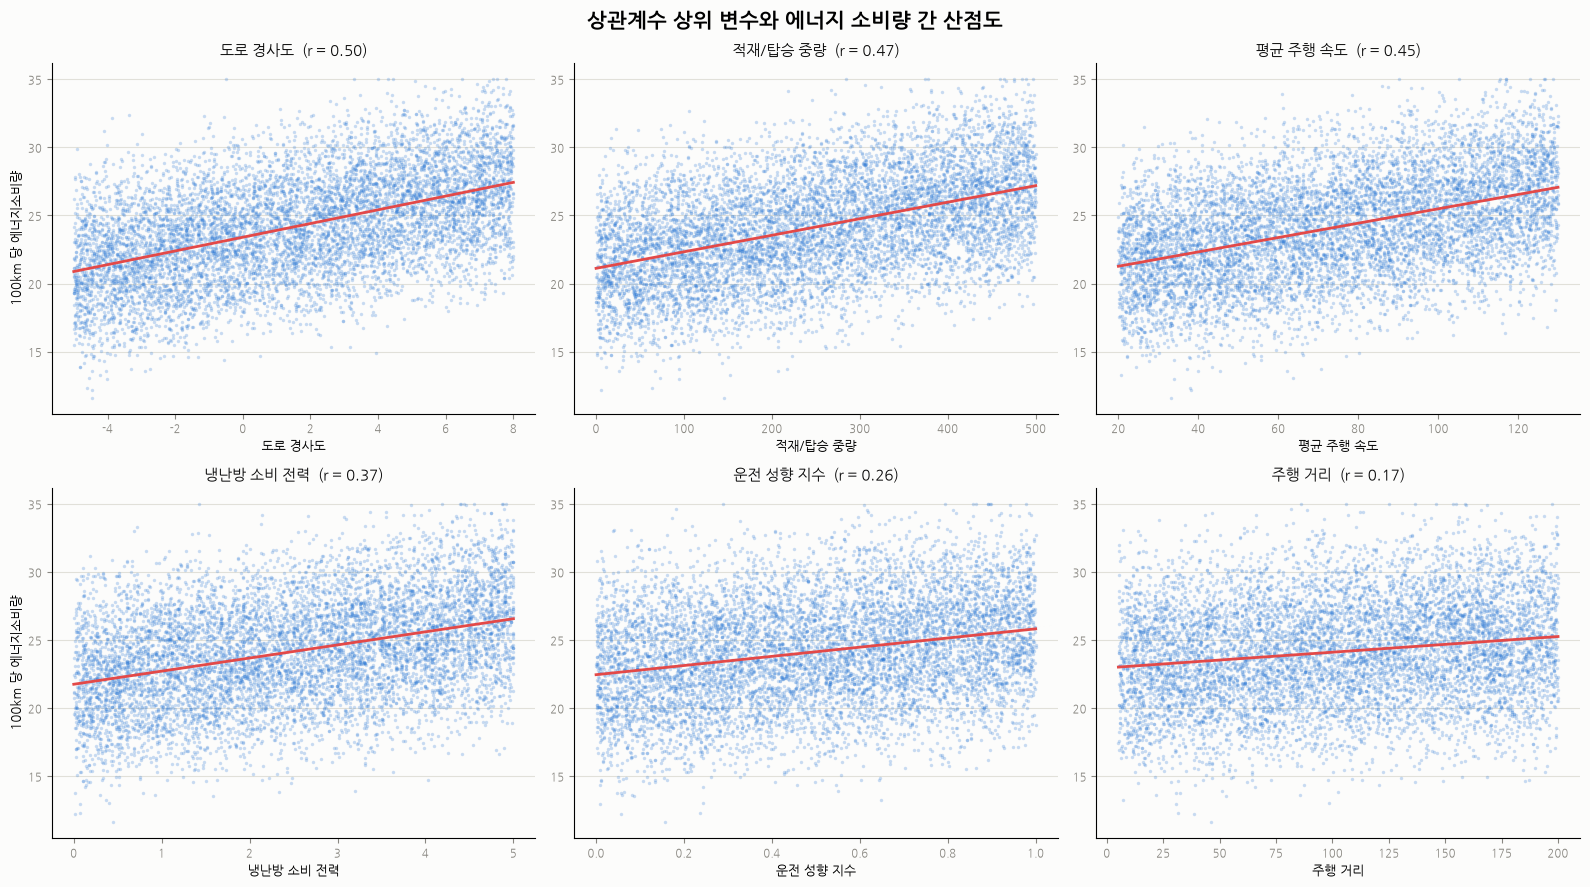

In [41]:
# 상관계수 절댓값 기준 상위 6개 변수 선정
top_features = target_corr.abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.patch.set_facecolor(SURFACE)
axes = axes.flatten()

for i, col in enumerate(top_features):
    ax = axes[i]
    ax.set_facecolor(SURFACE)
    ax.scatter(ev_df[col], ev_df[target_col], s=6, alpha=0.25, color=COLOR_FEATURE, linewidths=0)

    # 선형 추세선 추가 (실제 관계가 선형인지 비선형인지 눈으로 비교하기 위함)
    z = np.polyfit(ev_df[col], ev_df[target_col], 1)
    x_line = np.linspace(ev_df[col].min(), ev_df[col].max(), 100)
    ax.plot(x_line, np.poly1d(z)(x_line), color='#e34948', linewidth=2)

    ax.set_title(f'{col}  (r = {target_corr[col]:.2f})', fontsize=11, color=INK_PRIMARY)
    ax.set_xlabel(col, fontsize=9)
    if i % 3 == 0:
        ax.set_ylabel(target_col, fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(colors=INK_MUTED, labelsize=8)
    ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.8)
    ax.set_axisbelow(True)

fig.suptitle('상관계수 상위 변수와 에너지 소비량 간 산점도', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


## EDA 요약

- 데이터는 총 **8,000행 × 10열**이며, **결측치와 중복 행이 없어** 전처리 부담이 적은 깨끗한 데이터셋입니다.
- 에너지 소비량과 상관관계가 높은 변수 순서(절댓값 기준): **도로 경사도(도로 경사도, r≈0.50) > 적재중량(적재/탑승 중량, r≈0.47) > 속도(평균 주행 속도, r≈0.45) > HVAC 전력(냉난방 소비 전력, r≈0.37) > 운전성향지수(운전 성향 지수, r≈0.26) > 주행거리(주행 거리, r≈0.17)** 순으로 나타났습니다.
- 외기온도(외기 온도, r≈-0.16), 타이어 공기압(타이어 공기압, r≈-0.10), 배터리 온도(배터리 온도, r≈-0.09)는 선형 상관계수는 낮지만, 실제로는 극단적인 온도(너무 춥거나 더운 경우)에서 소비량이 높아지는 **비선형(U자형) 패턴**일 가능성이 있어 산점도로 형태를 함께 확인했습니다. 모델링 단계에서는 구간화(binning)나 절댓값 변환 등을 고려할 필요가 있습니다.
- IQR 기준 이상치는 일부 존재하지만, 데이터 전체 분포를 왜곡할 정도로 심하지는 않은 것으로 보입니다.

## 다음 단계: 문제 정의로 확장하기

이 EDA를 바탕으로, 다음 시간에는 아래와 같은 방향으로 **"단순 회귀를 넘어선 문제 정의"**를 논의해볼 수 있습니다.
- 실시간 주행 조건을 반영해 **잔여 주행가능거리(Range)를 재계산**해주는 서비스
- 운전 습관(운전 성향 지수)과 소비량의 관계를 활용한 **에코 드라이빙 코칭/피드백** 서비스
- 경사도·속도·적재중량을 반영한 **배송/물류 차량의 에너지 효율 경로 추천**
- 외기온도·HVAC 사용량을 반영한 **계절별 충전 계획 및 배터리 관리 알림**


## 2부. 에너지 소비량 예측 모델링

### 비교할 네 가지 모델

1. **단순 선형회귀**: EDA에서 타겟과 Pearson 상관계수가 가장 높은 `도로 경사도` 하나만 사용합니다.
2. **다중 선형회귀**: 9개 변수를 모두 사용합니다. 서로 다른 단위를 맞추기 위해 `StandardScaler`를 파이프라인 안에 적용합니다.
3. **Random Forest**: 여러 결정트리를 평균내 비선형성과 변수 간 상호작용을 학습합니다.
4. **XGBoost**: 앞선 트리의 오차를 순차적으로 보완하여 복잡한 관계를 학습합니다.

단순·다중 선형회귀의 차이는 **사용하는 독립변수 개수**입니다. 두 모델 모두 같은 선형 회귀 알고리즘이지만, 단순 회귀는 관계 설명용 기준선이고 다중 회귀는 다른 모델과 공정하게 경쟁하는 선형 기준선입니다.

### 검증 및 평가지표

- 모든 모델은 동일한 `train 80% / test 20%`와 `random_state=42`를 사용합니다.
- 트리 모델의 하이퍼파라미터는 train 내부 5-fold 교차검증에서 RMSE가 최소가 되도록 선택합니다.
- **MAE**는 평균적인 실무 오차, **RMSE**는 큰 오차 위험, **R²**는 전체 설명력, **RMAE**는 평균 소비량 대비 MAE 비율입니다.


In [42]:
# 모델링 라이브러리와 데이터 분리
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from xgboost import XGBRegressor
import joblib
import seaborn as sns

X = ev_df[feature_cols].copy()
y = ev_df[target_col].copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

simple_feature = '도로 경사도'
print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'단순 선형회귀 입력변수: {simple_feature}')
print(f'Test 타겟 평균: {y_test.mean():.3f} kWh/100km')


Train: (6400, 9) | Test: (1600, 9)
단순 선형회귀 입력변수: 도로 경사도
Test 타겟 평균: 24.031 kWh/100km


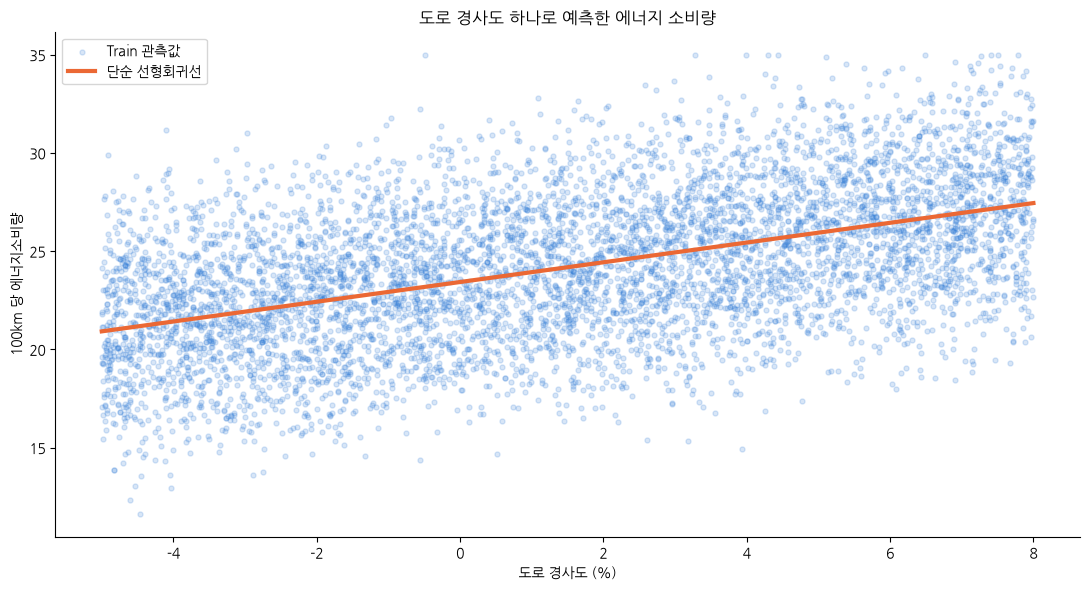

회귀식: 소비량 = 23.426 + (0.502 × 도로 경사도)


In [43]:
# 단순 선형회귀: 도로 경사도와 에너지 소비량의 직선 관계
simple_linear = LinearRegression()
simple_linear.fit(X_train[[simple_feature]], y_train)

x_line = np.linspace(X[simple_feature].min(), X[simple_feature].max(), 200)
y_line = simple_linear.predict(pd.DataFrame({simple_feature: x_line}))

fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(X_train[simple_feature], y_train, s=13, alpha=0.18, color=COLOR_FEATURE, label='Train 관측값')
ax.plot(x_line, y_line, color=COLOR_TARGET, lw=3, label='단순 선형회귀선')
ax.set(title='도로 경사도 하나로 예측한 에너지 소비량', xlabel='도로 경사도 (%)', ylabel='100km 당 에너지소비량')
ax.legend(); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()
print(f'회귀식: 소비량 = {simple_linear.intercept_:.3f} + ({simple_linear.coef_[0]:.3f} × 도로 경사도)')


### 다중 선형회귀의 표준화

적재 중량은 최대 500, 운전 성향 지수는 최대 1처럼 단위 차이가 큽니다. OLS 예측값 자체는 스케일링 전후가 거의 같지만, 수치 안정성과 표준화 계수 비교를 위해 다중 선형회귀에 표준화를 적용합니다. `Pipeline`을 사용하므로 scaler는 train에만 학습되어 데이터 누수가 없습니다. Random Forest와 XGBoost는 값의 순서와 분기점을 이용하므로 표준화하지 않습니다.


In [44]:
# 다중 선형회귀 및 트리 모델 하이퍼파라미터 탐색
multiple_linear = Pipeline([
    ('scale', StandardScaler()),
    ('model', LinearRegression())
])

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions={
        'n_estimators':[300, 500], 'max_depth':[None, 12, 20],
        'min_samples_leaf':[1, 2, 4], 'max_features':[0.7, 0.9, 1.0]
    }, n_iter=12, scoring='neg_root_mean_squared_error', cv=cv,
    random_state=42, n_jobs=-1
)

xgb_search = RandomizedSearchCV(
    XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=1),
    param_distributions={
        'n_estimators':[300, 500, 700], 'max_depth':[2, 3, 4],
        'learning_rate':[0.03, 0.05, 0.08], 'subsample':[0.8, 1.0],
        'colsample_bytree':[0.8, 1.0], 'reg_lambda':[1, 3, 5]
    }, n_iter=15, scoring='neg_root_mean_squared_error', cv=cv,
    random_state=42, n_jobs=-1
)

multiple_linear.fit(X_train, y_train)
rf_search.fit(X_train, y_train)
xgb_search.fit(X_train, y_train)

models = {
    '단순 선형회귀': simple_linear,
    '다중 선형회귀': multiple_linear,
    'Random Forest': rf_search.best_estimator_,
    'XGBoost': xgb_search.best_estimator_
}
print('Random Forest 최적값:', rf_search.best_params_)
print('XGBoost 최적값:', xgb_search.best_params_)


/home/aiuser/gg1th_ml_basic/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/aiuser/gg1th_ml_basic/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/aiuser/gg1th_ml_basic/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/aiuser/gg1th_ml_basic/.venv/lib/py

Random Forest 최적값: {'n_estimators': 500, 'min_samples_leaf': 2, 'max_features': 0.7, 'max_depth': None}
XGBoost 최적값: {'subsample': 0.8, 'reg_lambda': 5, 'n_estimators': 700, 'max_depth': 2, 'learning_rate': 0.08, 'colsample_bytree': 0.8}


In [45]:
# 동일 Test set에서 네 모델 평가
rows, predictions = [], {}
for name, model in models.items():
    model_X = X_test[[simple_feature]] if name == '단순 선형회귀' else X_test
    pred = model.predict(model_X)
    predictions[name] = pred
    mae = mean_absolute_error(y_test, pred)
    rows.append({'모델':name, 'R²':r2_score(y_test,pred), 'MAE':mae,
                 'RMSE':root_mean_squared_error(y_test,pred),
                 'RMAE (%)':mae/y_test.mean()*100})
results_df = pd.DataFrame(rows).set_index('모델').sort_values('RMSE')
display(results_df.round({'R²':4,'MAE':4,'RMSE':4,'RMAE (%)':2}))

# 모델별 train 5-fold CV RMSE: test 한 번의 우연과 순위가 같은지 확인
cv_rmse = {}
for name, model in models.items():
    model_X = X_train[[simple_feature]] if name == '단순 선형회귀' else X_train
    scores = cross_validate(model, model_X, y_train, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1)
    cv_rmse[name] = (-scores['test_score']).mean()
results_df['CV RMSE'] = pd.Series(cv_rmse)
display(results_df[['CV RMSE','RMSE']].sort_values('CV RMSE').round(4))


,R²,MAE,RMSE,RMAE (%)
모델,,,,
XGBoost,0.9470,0.6707,0.8463,2.79
다중 선형회귀,0.9246,0.8107,1.0093,3.37
Random Forest,0.9031,0.9161,1.1444,3.81
단순 선형회귀,0.2642,2.5464,3.1533,10.60


,CV RMSE,RMSE
모델,,
XGBoost,0.8694,0.8463
다중 선형회귀,1.0049,1.0093
Random Forest,1.2192,1.1444
단순 선형회귀,3.2457,3.1533


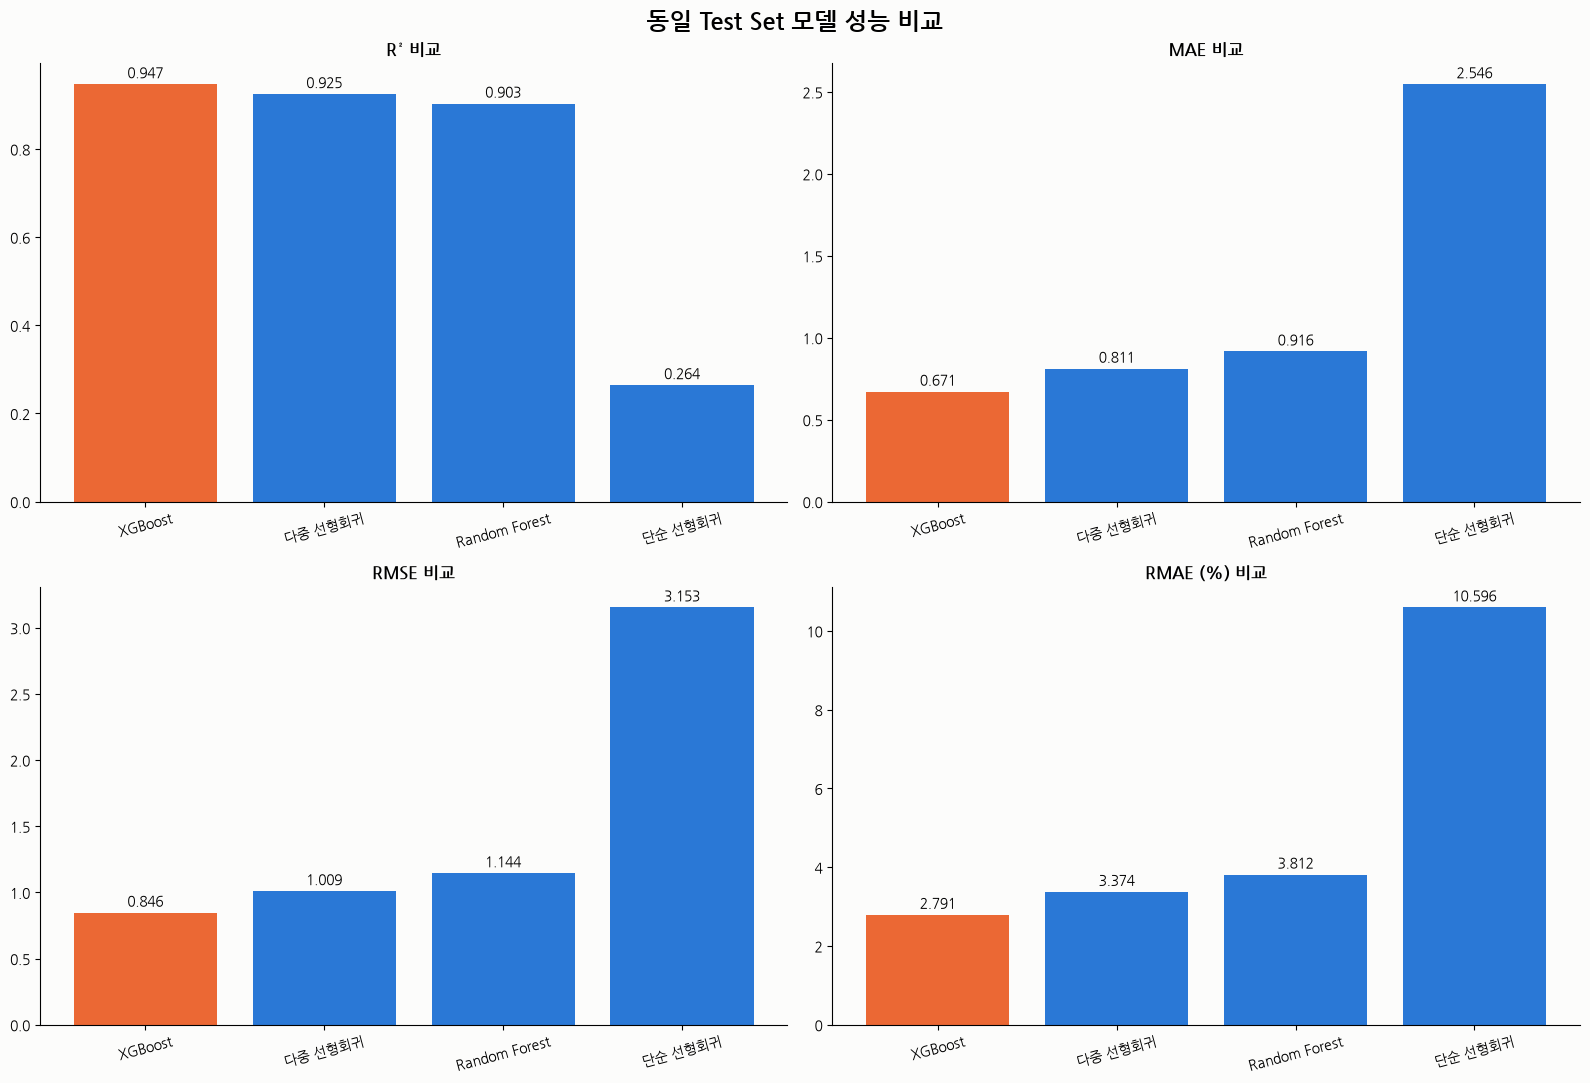

In [46]:
# Plot 1: 모델별 네 가지 지표 비교
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.patch.set_facecolor(SURFACE)
for ax, metric, higher in zip(axes.flat, ['R²','MAE','RMSE','RMAE (%)'], [True,False,False,False]):
    ordered = results_df.sort_values(metric, ascending=not higher)
    colors = [COLOR_TARGET if i==0 else COLOR_FEATURE for i in range(len(ordered))]
    bars = ax.bar(ordered.index, ordered[metric], color=colors)
    ax.bar_label(bars, fmt='%.3f', padding=3)
    ax.set_title(f'{metric} 비교', fontweight='bold'); ax.tick_params(axis='x', rotation=15)
    ax.spines[['top','right']].set_visible(False); ax.set_facecolor(SURFACE)
plt.suptitle('동일 Test Set 모델 성능 비교', fontsize=17, fontweight='bold')
plt.tight_layout(); plt.show()


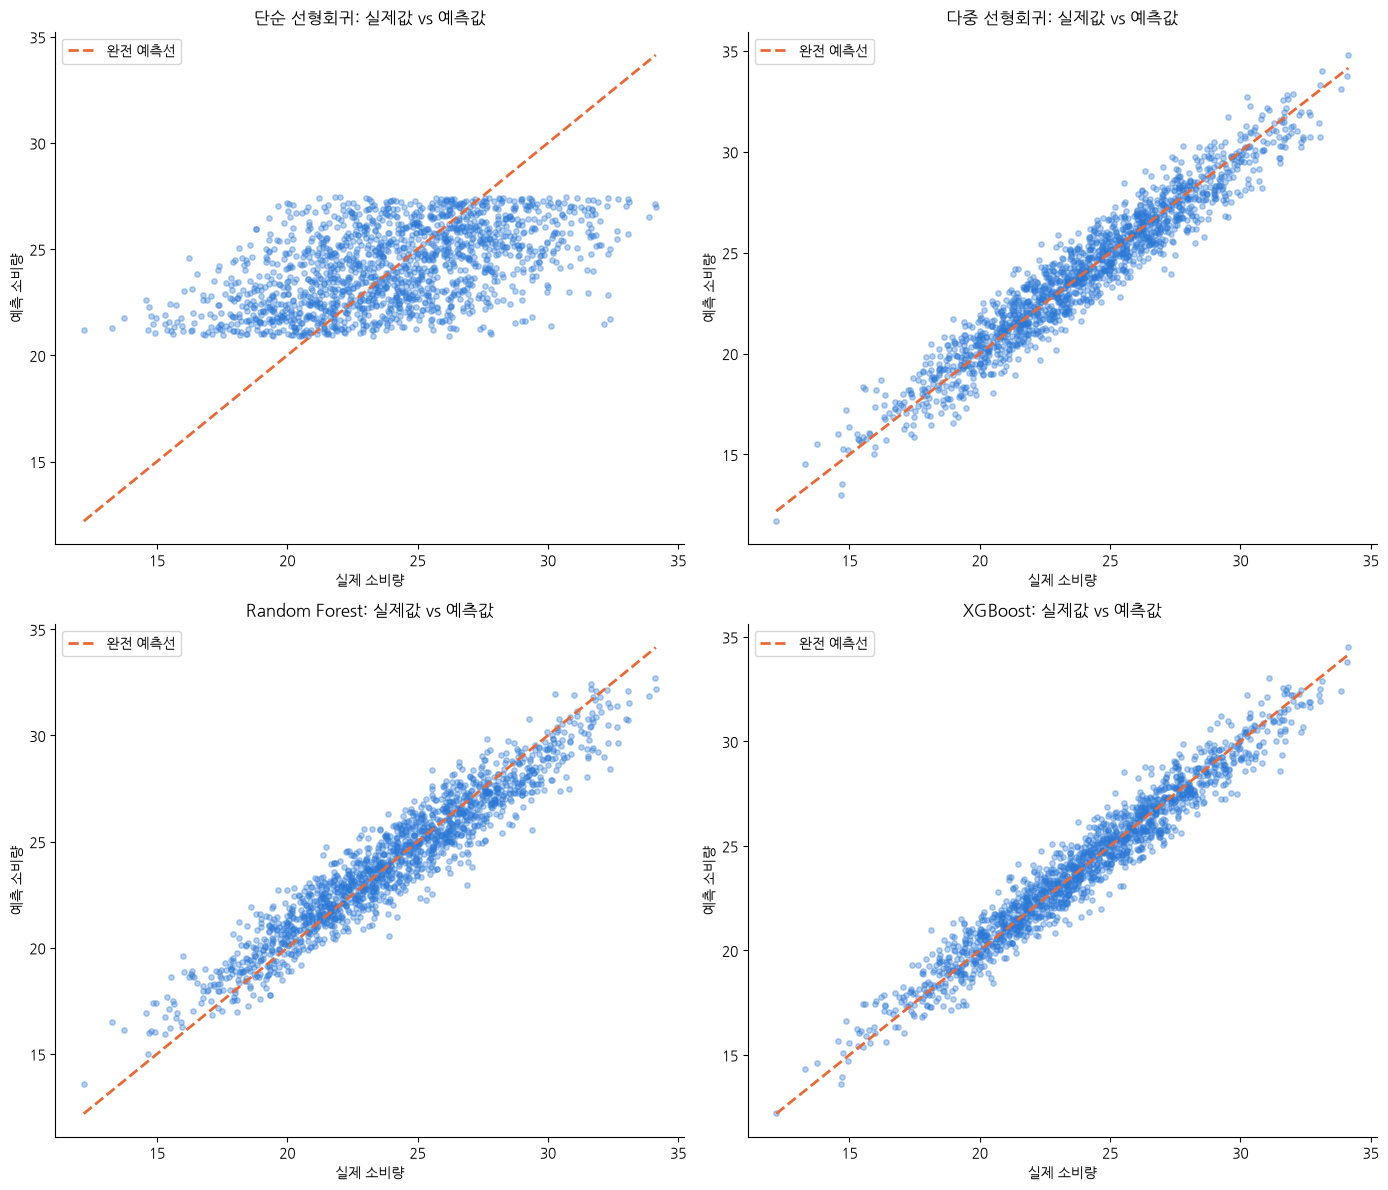

In [47]:
# Plot 2: 실제값과 예측값 정렬도
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
lims = [y_test.min(), y_test.max()]
for ax, (name, pred) in zip(axes.flat, predictions.items()):
    ax.scatter(y_test, pred, s=15, alpha=.35, color=COLOR_FEATURE)
    ax.plot(lims, lims, '--', lw=2, color=COLOR_TARGET, label='완전 예측선')
    ax.set(title=f'{name}: 실제값 vs 예측값', xlabel='실제 소비량', ylabel='예측 소비량')
    ax.legend(); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()


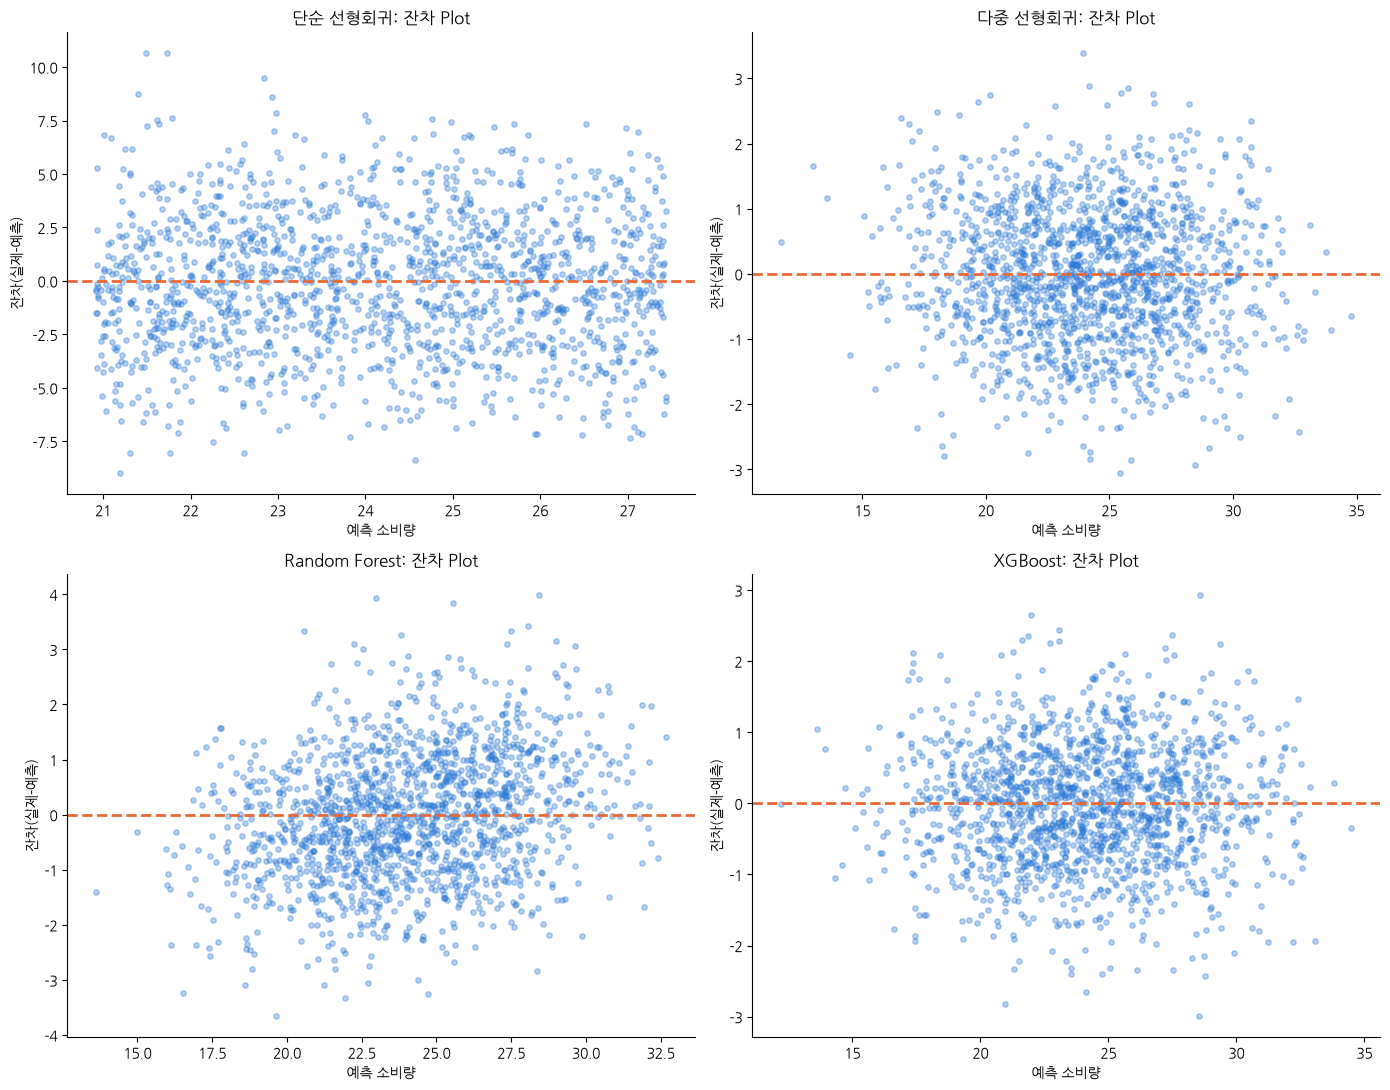

In [48]:
# Plot 3: 예측값에 따른 잔차 패턴
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for ax, (name, pred) in zip(axes.flat, predictions.items()):
    residual = y_test.to_numpy() - pred
    ax.scatter(pred, residual, s=15, alpha=.35, color=COLOR_FEATURE)
    ax.axhline(0, ls='--', lw=2, color=COLOR_TARGET)
    ax.set(title=f'{name}: 잔차 Plot', xlabel='예측 소비량', ylabel='잔차(실제-예측)')
    ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()


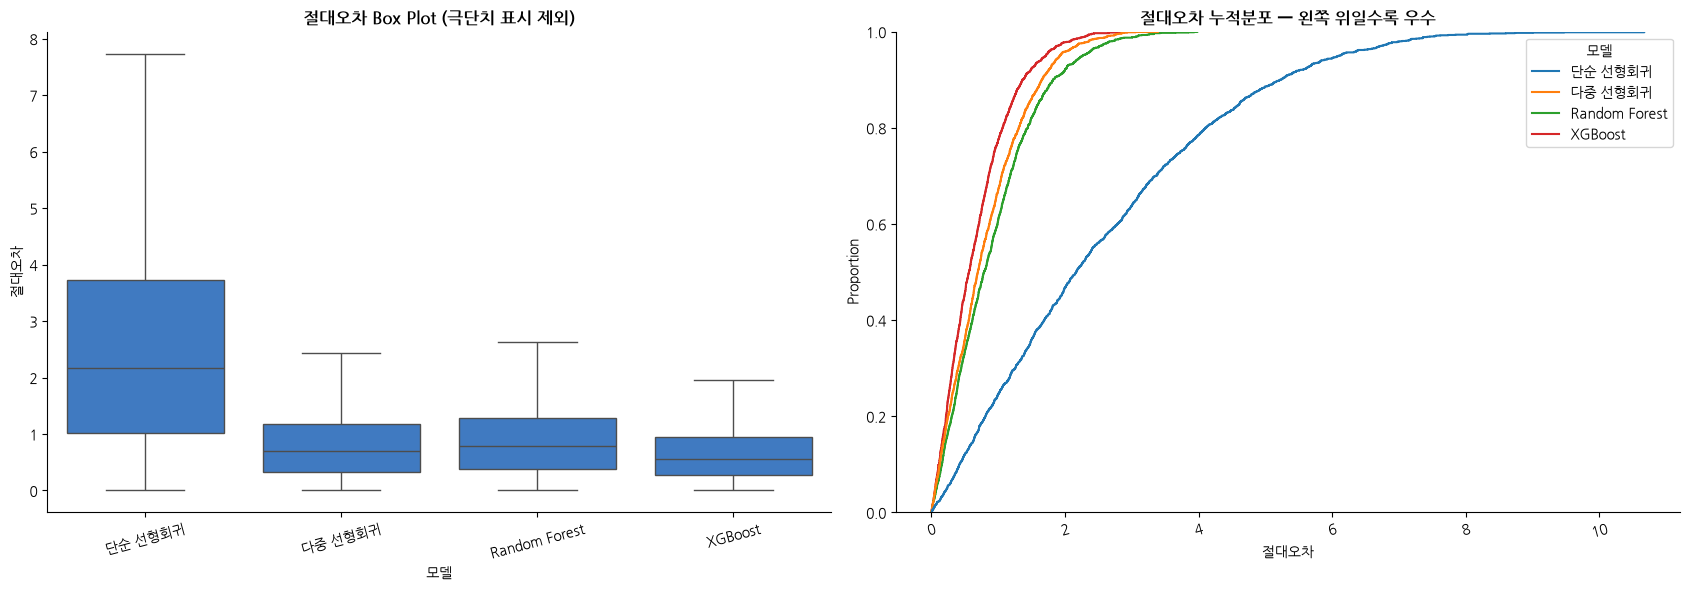

In [49]:
# Plot 4: 모델별 절대오차 분포 — 평균뿐 아니라 긴 꼬리도 비교
error_long = pd.concat([
    pd.DataFrame({'모델':name, '절대오차':np.abs(y_test.to_numpy()-pred)})
    for name,pred in predictions.items()
], ignore_index=True)
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
sns.boxplot(data=error_long, x='모델', y='절대오차', ax=axes[0], color=COLOR_FEATURE,
            showfliers=False)
axes[0].set_title('절대오차 Box Plot (극단치 표시 제외)', fontweight='bold')
sns.ecdfplot(data=error_long, x='절대오차', hue='모델', ax=axes[1])
axes[1].set_title('절대오차 누적분포 — 왼쪽 위일수록 우수', fontweight='bold')
for ax in axes: ax.tick_params(axis='x', rotation=15); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()


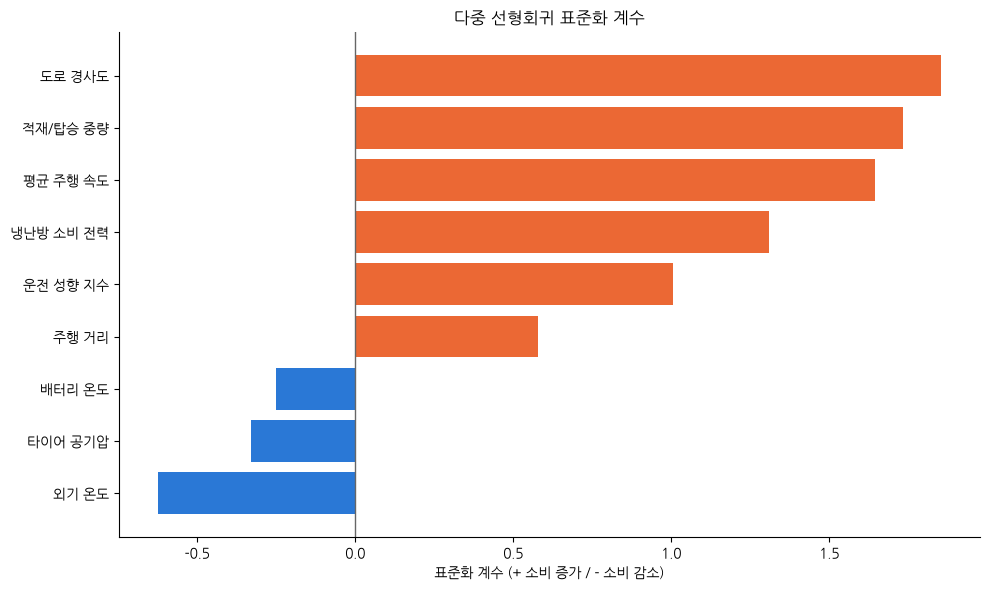

In [50]:
# Plot 5: 다중 선형회귀 표준화 계수 — 방향과 상대 영향
coef_df = pd.DataFrame({
    '변수': feature_cols,
    '표준화 계수': multiple_linear.named_steps['model'].coef_
}).sort_values('표준화 계수')
fig, ax = plt.subplots(figsize=(10, 6))
colors = [COLOR_TARGET if v>0 else '#2a78d6' for v in coef_df['표준화 계수']]
ax.barh(coef_df['변수'], coef_df['표준화 계수'], color=colors)
ax.axvline(0, color='#666666', lw=1)
ax.set(title='다중 선형회귀 표준화 계수', xlabel='표준화 계수 (+ 소비 증가 / - 소비 감소)')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()


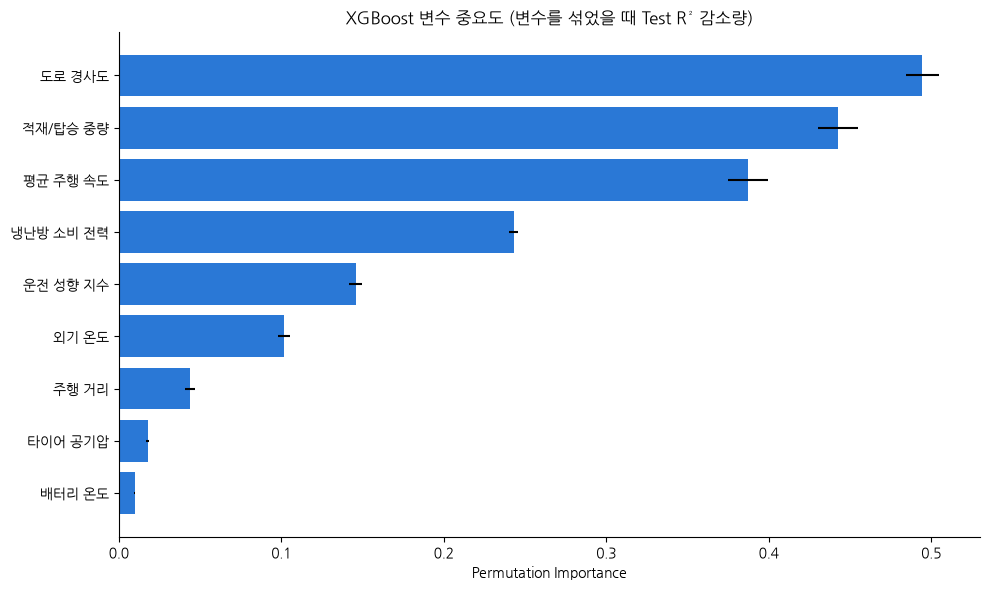

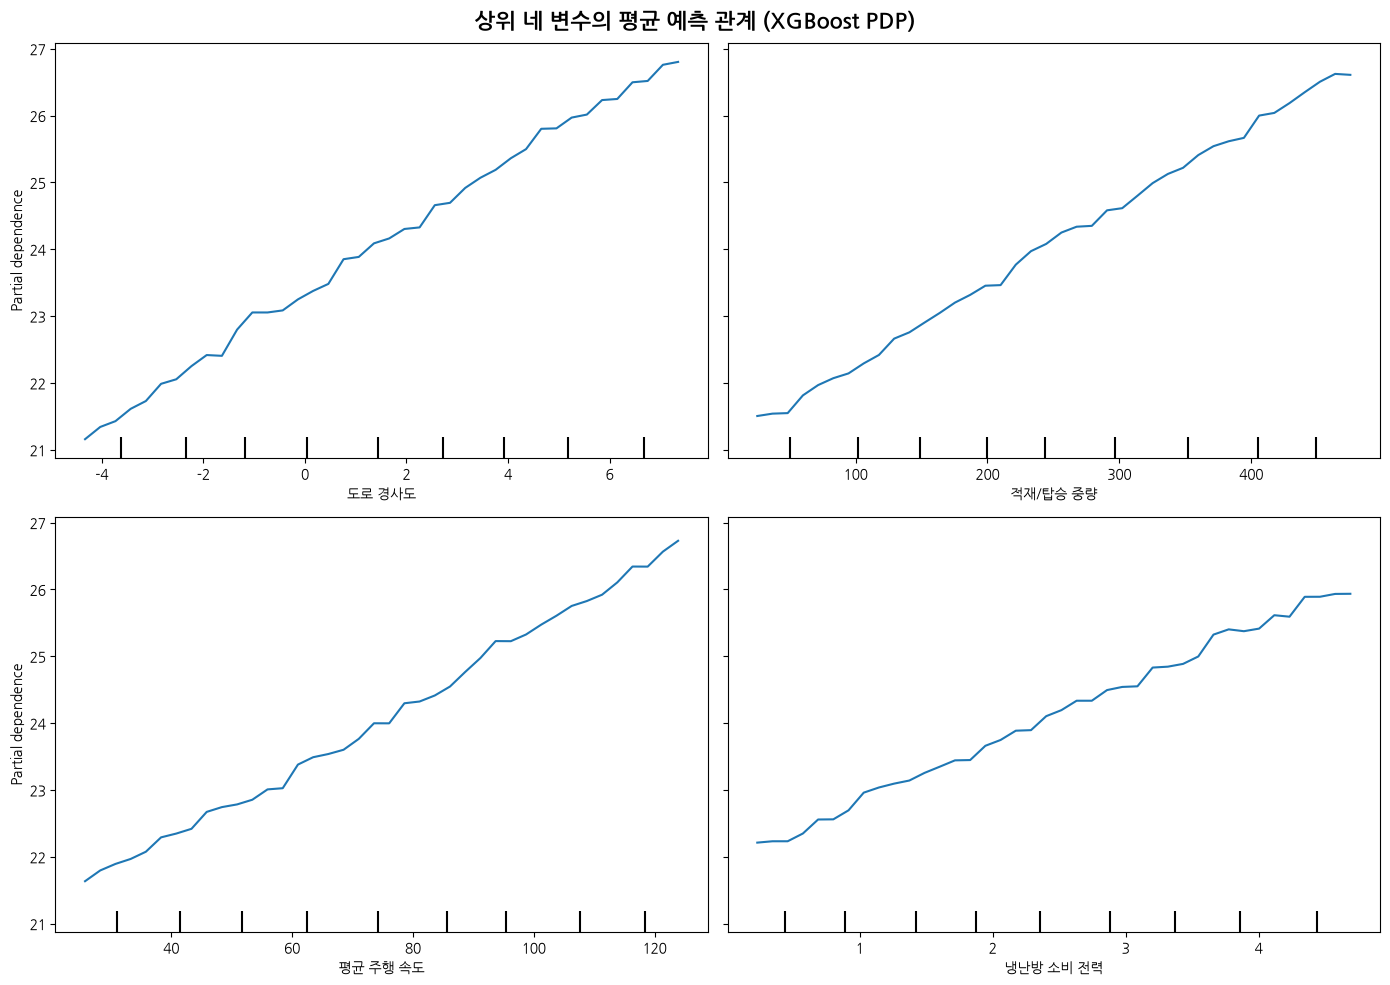

In [51]:
# Plot 6: 최우수 트리 모델의 Permutation Importance와 상위 변수 PDP
xgb_best = models['XGBoost']
perm = permutation_importance(xgb_best, X_test, y_test, n_repeats=10,
                              random_state=42, scoring='r2', n_jobs=-1)
importance_df = pd.DataFrame({'변수':feature_cols, '중요도':perm.importances_mean,
                              '표준편차':perm.importances_std}).sort_values('중요도')
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importance_df['변수'], importance_df['중요도'], xerr=importance_df['표준편차'], color=COLOR_FEATURE)
ax.set(title='XGBoost 변수 중요도 (변수를 섞었을 때 Test R² 감소량)', xlabel='Permutation Importance')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

top4 = importance_df.tail(4)['변수'].tolist()[::-1]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
PartialDependenceDisplay.from_estimator(xgb_best, X_test, features=top4,
                                        grid_resolution=40, ax=axes)
plt.suptitle('상위 네 변수의 평균 예측 관계 (XGBoost PDP)', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()


## 최종 결론

- 단순 선형회귀는 도로 경사도 하나의 설명력을 보여주는 기준선입니다.
- 다중 선형회귀가 크게 개선되면 여러 주행 조건의 **가산적 선형효과**가 중요하다는 뜻입니다.
- XGBoost 또는 Random Forest가 다중 선형회귀보다 개선되면 단순 합으로 표현하기 어려운 **비선형성·상호작용**이 존재한다는 근거입니다.
- 최종 선택은 교차검증으로 튜닝한 뒤 미사용 test RMSE가 가장 낮은 모델로 하며, MAE·RMAE·R²가 같은 방향인지 함께 확인합니다.


In [52]:
# 실제 평가값을 이용한 결론과 최종 모델 저장
best_name = results_df['RMSE'].idxmin()
best_model = models[best_name]
best = results_df.loc[best_name]
multi = results_df.loc['다중 선형회귀']
simple = results_df.loc['단순 선형회귀']

print('[모델링 결론]')
print(f'1) 단순 선형회귀: R²={simple["R²"]:.4f}, MAE={simple["MAE"]:.3f}, RMSE={simple["RMSE"]:.3f}')
print(f'2) 다중 선형회귀: R²={multi["R²"]:.4f}, MAE={multi["MAE"]:.3f}, RMSE={multi["RMSE"]:.3f}')
print(f'3) 최종 선택: {best_name} — R²={best["R²"]:.4f}, MAE={best["MAE"]:.3f}, RMSE={best["RMSE"]:.3f}, RMAE={best["RMAE (%)"]:.2f}%')
print(f'4) 다중 선형회귀 대비 RMSE 감소율={(multi["RMSE"]-best["RMSE"])/multi["RMSE"]*100:.1f}%')
print('5) 운영 시 평균 오차는 MAE, 큰 오차 위험은 RMSE, 전체 설명력은 R²를 함께 모니터링합니다.')

joblib.dump(best_model, 'ev_best_model.pkl')
print('\n저장 완료: ev_best_model.pkl')
print('주의: 저장 모델의 입력 DataFrame 컬럼명도 위의 한글 9개 컬럼을 사용합니다.')
print('저장 객체:', best_model)


[모델링 결론]
1) 단순 선형회귀: R²=0.2642, MAE=2.546, RMSE=3.153
2) 다중 선형회귀: R²=0.9246, MAE=0.811, RMSE=1.009
3) 최종 선택: XGBoost — R²=0.9470, MAE=0.671, RMSE=0.846, RMAE=2.79%
4) 다중 선형회귀 대비 RMSE 감소율=16.2%
5) 운영 시 평균 오차는 MAE, 큰 오차 위험은 RMSE, 전체 설명력은 R²를 함께 모니터링합니다.

저장 완료: ev_best_model.pkl
주의: 저장 모델의 입력 DataFrame 컬럼명도 위의 한글 9개 컬럼을 사용합니다.
저장 객체: XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.08, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=2,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=N